# **Thompson Sampling from Scratch**

## 0.ライブラリのインポートとデータの生成

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
true_probs = [0.2, 0.34, 0.5, 0.66, 0.8]
n_bandits = len(true_probs)
n_rounds = 500

## 1.アルゴリズム

多腕バンディット問題をベイズのようなアプローチで解決するアルゴリズム。各スロットの当たり確率をベータ分布でモデル化し、試行結果に応じて分布を更新しながら最適なスロットを探索する。  
UCBが「信頼区間の上限」という決定論的な値で選ぶのに対して、Thompson Samplingでは確率的にサンプリングして選ぶ。

### 1.1.ベータ分布

0〜1の値をとる確率分布であり、スロットの当たり確率のモデル化に適している。
$$Beta(\alpha, \beta)$$
試行を重ねるほど分布が鋭くなり、真の当たり確率に収束していく。

In [19]:
def thompson_sampling(n_bandits, n_rounds, true_probs):
  alpha = np.ones(n_bandits)
  beta = np.ones(n_bandits)
  choices = []
  rewards = []
  regrets = []

  best_prob = max(true_probs)

  for n in range(n_rounds):
    samples = np.random.beta(alpha, beta)
    chosen = np.argmax(samples)
    reward = np.random.binomial(1, true_probs[chosen])

    if reward == 1:
      alpha[chosen] += 1
    else:
      beta[chosen] += 1

    choices.append(chosen)
    rewards.append(reward)
    regrets.append(best_prob - true_probs[chosen])

  return choices, rewards, alpha, beta, regrets

choices, rewards, alpha, beta, regrets = thompson_sampling(n_bandits, n_rounds, true_probs)

## 2.モデルの可視化

### 2.1.各スロットの選択回数

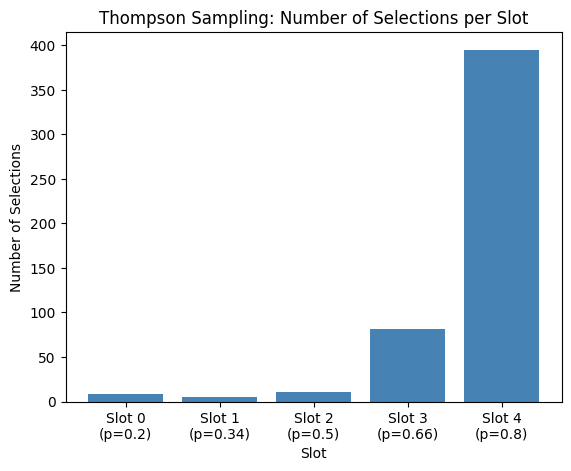

In [20]:
N = [choices.count(i) for i in range(n_bandits)]
plt.bar(range(n_bandits), N, color='steelblue')
plt.xticks(range(n_bandits), [f'Slot {i}\n(p={true_probs[i]})' for i in range(n_bandits)])
plt.xlabel("Slot")
plt.ylabel("Number of Selections")
plt.title("Thompson Sampling: Number of Selections per Slot")
plt.show()

### 2.2.累積報酬

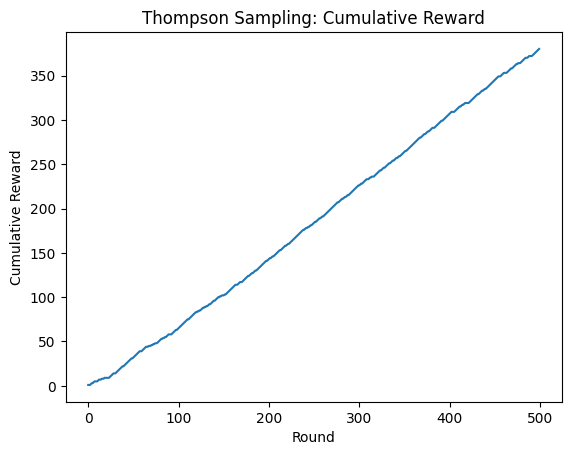

In [21]:
cumulative_rewards = np.cumsum(rewards)
plt.plot(cumulative_rewards)
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.title("Thompson Sampling: Cumulative Reward")
plt.show()

### 2.3.ベータ分布の収束

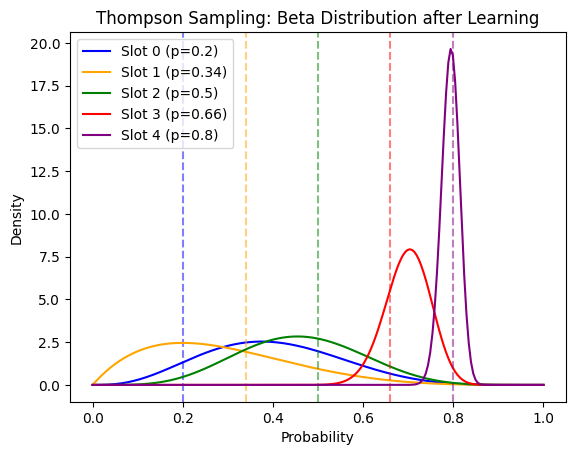

In [22]:
x = np.linspace(0, 1, 200)
colors = ['blue', 'orange', 'green', 'red', 'purple']
for i in range(n_bandits):
  from scipy.stats import beta as beta_dist
  y = beta_dist.pdf(x, alpha[i], beta[i])
  plt.plot(x, y, label=f'Slot {i} (p={true_probs[i]})', color=colors[i])
  plt.axvline(true_probs[i], linestyle='--', color=colors[i], alpha=0.5)
plt.xlabel("Probability")
plt.ylabel("Density")
plt.title("Thompson Sampling: Beta Distribution after Learning")
plt.legend()
plt.show()

## 3.検証

### 3.1.regretの推移

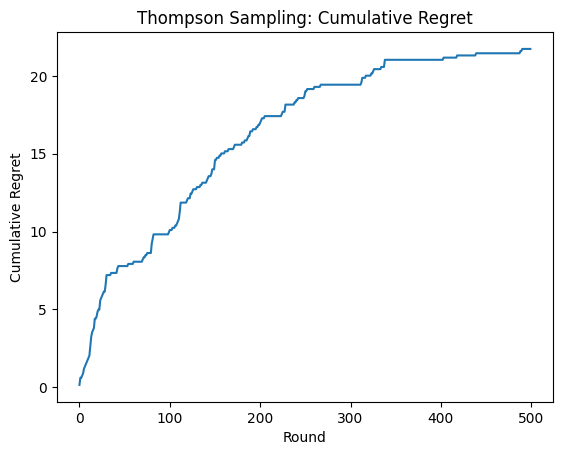

In [23]:
cumulative_regret = np.cumsum(regrets)
plt.plot(cumulative_regret)
plt.xlabel("Round")
plt.ylabel("Cumulative Regret")
plt.title("Thompson Sampling: Cumulative Regret")
plt.show()